In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

In [2]:
EVALUATION = False
root_dir = '/bohr/train-d2jt/v1/data_train/' if EVALUATION else '/home/stefan/Downloads/train_v1/data_train'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Data

In [3]:
def prep_df(df: pd.DataFrame):
    X = df.loc[:, ["[L2M]_0", "[D]_0", "[L]_0"]].copy()

    # feature engineering
    X["L_over_D"] = X["[L]_0"] / (X["[D]_0"] + 1e-8)
    X["D_over_L"] = X["[D]_0"] / (X["[L]_0"] + 1e-8)

    X["log_L2M"] = np.log(X["[L2M]_0"] + 1e-8)
    X["log_LD"] = np.log(X["L_over_D"] + 1e-8)
    X["log_L"] = np.log(X["[L]_0"] + 1e-8)
    X["log_D"] = np.log(X["[D]_0"] + 1e-8)

    if "T1/2" in df:
        y = df["T1/2"]
        return X, y
    return X

In [4]:
data = pd.read_csv(f'{root_dir}/training_data.dat')
X, y = prep_df(data)

X.head()

,[L2M]_0,[D]_0,[L]_0,L_over_D,D_over_L,log_L2M,log_LD,log_L,log_D
0,1.0,1.0,0.0,0.0,1.000000e+08,1.000000e-08,-18.420681,-18.420681,1.000000e-08
1,1.0,1.0,2.5,2.5,4.000000e-01,1.000000e-08,0.916291,0.916291,1.000000e-08
2,1.0,1.0,5.0,5.0,2.000000e-01,1.000000e-08,1.609438,1.609438,1.000000e-08
3,1.0,1.0,7.5,7.5,1.333333e-01,1.000000e-08,2.014903,2.014903,1.000000e-08
4,1.0,1.0,10.0,10.0,1.000000e-01,1.000000e-08,2.302585,2.302585,1.000000e-08


In [5]:
pf = PolynomialFeatures(degree=2, include_bias=True)
X_poly = pf.fit_transform(X)
poly_names = pf.get_feature_names_out()
X = pd.DataFrame(X_poly, columns=poly_names)

X.head()

,1,[L2M]_0,[D]_0,[L]_0,L_over_D,D_over_L,log_L2M,log_LD,log_L,log_D,...,log_L2M^2,log_L2M log_LD,log_L2M log_L,log_L2M log_D,log_LD^2,log_LD log_L,log_LD log_D,log_L^2,log_L log_D,log_D^2
0,1.0,1.0,1.0,0.0,0.0,1.000000e+08,1.000000e-08,-18.420681,-18.420681,1.000000e-08,...,1.000000e-16,-1.842068e-07,-1.842068e-07,1.000000e-16,339.321479,339.321479,-1.842068e-07,339.321479,-1.842068e-07,1.000000e-16
1,1.0,1.0,1.0,2.5,2.5,4.000000e-01,1.000000e-08,0.916291,0.916291,1.000000e-08,...,1.000000e-16,9.162907e-09,9.162907e-09,1.000000e-16,0.839589,0.839589,9.162907e-09,0.839589,9.162907e-09,1.000000e-16
2,1.0,1.0,1.0,5.0,5.0,2.000000e-01,1.000000e-08,1.609438,1.609438,1.000000e-08,...,1.000000e-16,1.609438e-08,1.609438e-08,1.000000e-16,2.590290,2.590290,1.609438e-08,2.590290,1.609438e-08,1.000000e-16
3,1.0,1.0,1.0,7.5,7.5,1.333333e-01,1.000000e-08,2.014903,2.014903,1.000000e-08,...,1.000000e-16,2.014903e-08,2.014903e-08,1.000000e-16,4.059834,4.059834,2.014903e-08,4.059834,2.014903e-08,1.000000e-16
4,1.0,1.0,1.0,10.0,10.0,1.000000e-01,1.000000e-08,2.302585,2.302585,1.000000e-08,...,1.000000e-16,2.302585e-08,2.302585e-08,1.000000e-16,5.301898,5.301898,2.302585e-08,5.301898,2.302585e-08,1.000000e-16


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) 

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
class CustomDataset(Dataset):
    def __init__(self, initial_c, t12):
        self.input = torch.tensor(initial_c, dtype=torch.float32)
        self.label = torch.tensor(t12, dtype=torch.float32)

    def __len__(self):
        return len(self.label)

    def __getitem__(self, i):
        return self.input[i], self.label[i]

In [8]:
dataset = CustomDataset(X_train, y_train.values)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

test_ds = CustomDataset(X_test, y_test.values)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [9]:
# sanity check
batch = next(iter(dataloader))
[b.shape for b in batch]

[torch.Size([64, 55]), torch.Size([64])]

# Model

In [12]:
class MyModel(nn.Module):
    def __init__(self, n_feats):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(n_feats, 32)
        self.fc2 = nn.Linear(32, 64)
        self.fc3 = nn.Linear(64, 128)
        self.fc4 = nn.Linear(128, 128)
        self.fc5 = nn.Linear(128, 1)
        self.relu = nn.ReLU()
        self.elu = nn.ELU()
        self.Mish = nn.Mish()
        self.norm1 = nn.LayerNorm([32])
        self.norm2 = nn.LayerNorm([64])
        self.norm3 = nn.LayerNorm([128])
    def forward(self, x):
        x1 = self.elu(self.norm1(self.fc1(x)))
        x2 = self.Mish(self.norm2(self.fc2(x1)))
        x3 = self.relu(self.norm3(self.fc3(x2)))
        x4 = torch.nn.functional.leaky_relu(self.fc4(x3))
        x5 = self.fc5(x4)

        return x5

In [69]:
model = MyModel(n_feats=len(X.columns)).to(device)

x = batch[0].to(device)
model(x).shape

torch.Size([64, 1])

# Training

In [70]:
epochs = 400
lr = 1e-2

In [71]:
def train(model, losses = [], do_print=False):
    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs*len(dataloader), eta_min=1e-6)

    for epoch in tqdm(range(1, epochs+1)):
        train_loss, test_loss = 0, 0

        model.train()
        for input, label in dataloader:
            input, label = input.to(device), label.to(device)

            optimizer.zero_grad()
            output = model(input)
            output = torch.squeeze(output)
            loss = criterion(output, label)

            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            losses.append(loss.item())

        model.eval()
        for input, label in test_loader:
            input, label = input.to(device), label.to(device)
            with torch.no_grad():
                output = model(input)
                output = torch.squeeze(output)
                loss = criterion(output, label)
            test_loss += loss.item()
            
        avg_loss = train_loss / len(dataloader)
        avg_test = test_loss / len(test_loader)

        if epoch % 50 == 0 and do_print:
            print(f'epoch {epoch}; train_loss={avg_loss:.4f}, test_loss={avg_test:.4f}')

    return avg_test, losses

 14%|█▎        | 54/400 [00:01<00:09, 34.80it/s]

epoch 50; train_loss=15.9484, test_loss=12.5195


 26%|██▋       | 106/400 [00:03<00:08, 33.85it/s]

epoch 100; train_loss=11.1982, test_loss=14.4594


 38%|███▊      | 154/400 [00:04<00:07, 35.00it/s]

...

epoch 300; train_loss=2.0730, test_loss=3.3627


 88%|████████▊ | 354/400 [00:10<00:01, 34.37it/s]

epoch 350; train_loss=0.9355, test_loss=1.4134


100%|██████████| 400/400 [00:11<00:00, 33.87it/s]


epoch 400; train_loss=0.6311, test_loss=1.3556


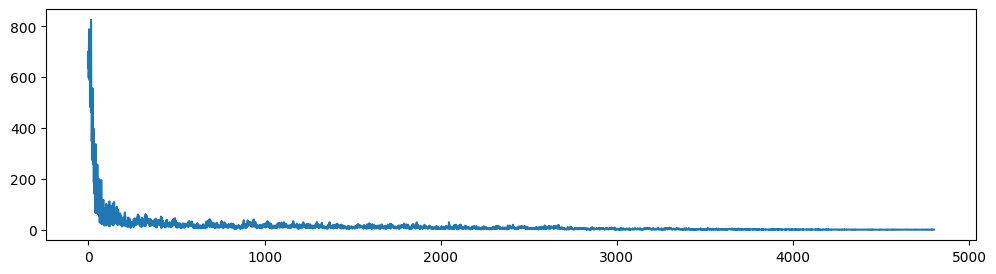

In [72]:
if not EVALUATION:
    _, losses = train(model, do_print=True)

    plt.figure(figsize=(12, 3))
    plt.plot(losses)

In [73]:
if EVALUATION:
    best_score = math.inf
    best_model = None

    for i in range(5):
        new_model = MyModel(n_feats=len(X.columns)).to(device)
        avg_test, losses = train(new_model)
        if avg_test < best_score:
            print(f"Saving new best model, test_loss={avg_test}")
            best_score = avg_test
            best_model = new_model
else:
    best_model = model

# Submission

In [74]:
model = best_model

if EVALUATION:
    torch.save(model.state_dict(), '/personal/NOAI2025_2_model.pth') 

In [75]:
# %%
if os.environ.get("DATA_PATH"):
    base = os.environ["DATA_PATH"]
    val_path = os.path.join(
        base, "data_val", "val_data_question.dat"
    )
    test_path = os.path.join(
        base, "data_test", "test_data_question.dat"
    )
    outs = []
    for split, path in (("val", val_path), ("test", test_path)):
        dfq = pd.read_csv(path)
        Xq = prep_df(dfq)
        Xq = pf.transform(Xq)
        Xq = scaler.transform(Xq)
        inputs = torch.tensor(
            Xq, dtype=torch.float32
        ).to(device)
        with torch.no_grad():
            preds = (
                model(inputs)
                .squeeze()
                .cpu()
                .numpy()
            )
        df_sub = pd.DataFrame({
            "Exp #": range(len(preds)),
            "t12_simulated": [
                f"{p:.4e}" for p in preds
            ]
        })
        fname = f"submission_{split}.csv"
        df_sub.to_csv(fname, index=False)
        outs.append(fname)

    import zipfile
    with zipfile.ZipFile("submission.zip", "w") as zf:
        for fn in outs:
            zf.write(fn)